# Layer 0: Baseline for South Korea Monthly Total Exports

## Introduction

South Korea's monthly total exports are highly cyclical and dominated by
semiconductors, which run roughly 35 to 70% of exports depending on where the
memory chip cycle stands. That makes the series economically important and a
hard forecasting target.

This notebook builds the baseline every later model in the project has to beat:
a SARIMA model fit on the exports series alone, benchmarked against naive and
seasonal naive random walks. We start here deliberately, following Occam's
razor. Alt data, text sentiment, and satellite imagery in later notebooks only
earn their added complexity if they beat this anchor out of sample, across a
rolling walk-forward backtest, not on a single split.

Target series: `XTEXVA01KRM667S`, Korea's total goods exports in USD,
seasonally adjusted, sourced from the OECD Main Economic Indicators via FRED.
No API key required. Pulled directly from FRED's CSV endpoint.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
from data import load_exports
from walk_forward import walk_forward, rmse, mape
from baseline import (
    naive_forecast,
    seasonal_naive_forecast,
    select_sarima_order,
    make_sarima_forecaster,
)

plt.rcParams["figure.figsize"] = (11, 4)

## Methodology

Data: monthly series from 1990 onward, 436 observations as of this run.
Pre-1990 data exists but reflects a structurally different, smaller export
base and adds noise rather than signal.

Models:
- Naive: next month equals this month, a random walk.
- Seasonal naive: next month equals the same month last year.
- SARIMA(p,d,q)(P,D,Q,12): order chosen once by AIC grid search on the
  pre-test data. Parameters re-estimated at every walk-forward origin.


Validation: rolling origin walk-forward, expanding window, one month ahead
forecasts, 36 origins. At each origin the model
only sees data up to that point preventing look-ahead.

Limitation: this FRED series is already seasonally adjusted and
periodically revised by the OECD. A true real-time backtest would need the
vintage as originally published at each origin. Using the current, revised
series is a mild optimistic bias, worth revisiting if a later layer claims a
narrow win over this baseline.

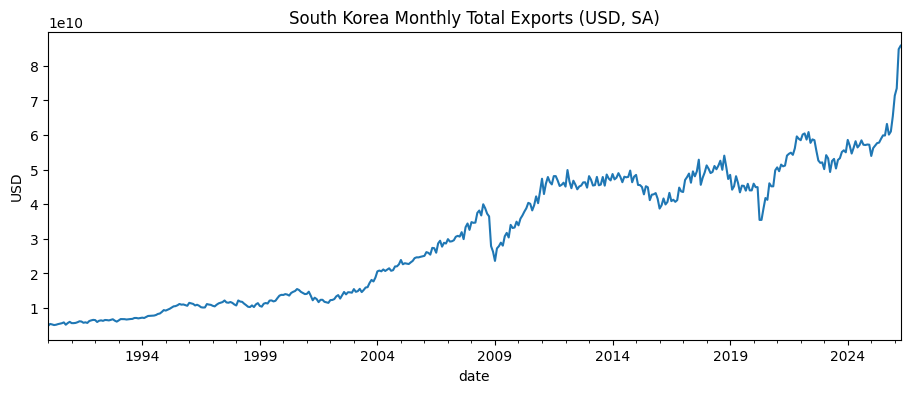

436 observations, 1990-01-01 to 2026-04-01


In [2]:
series = load_exports()
series.plot(title="South Korea Monthly Total Exports (USD, SA)")
plt.ylabel("USD")
plt.show()

print(f"{len(series)} observations, {series.index.min().date()} to {series.index.max().date()}")

In [3]:
N_TEST = 36
HORIZON = 1

order_selection_cutoff = len(series) - N_TEST
order, seasonal_order = select_sarima_order(series.iloc[:order_selection_cutoff])
print(f"SARIMA order selected on pre-test data: {order} x {seasonal_order}")

SARIMA order selected on pre-test data: (2, 1, 2) x (1, 1, 1, 12)


In [4]:
models = {
    "naive": naive_forecast,
    "seasonal_naive": seasonal_naive_forecast,
    "sarima": make_sarima_forecaster(order, seasonal_order),
}

results = {
    name: walk_forward(series, fn, n_test=N_TEST, horizon=HORIZON)
    for name, fn in models.items()
}

for name, df in results.items():
    print(f"{name:>15}  RMSE={rmse(df):>14,.0f}  MAPE={mape(df):>6.2f}%")

          naive  RMSE= 2,847,251,652  MAPE=  3.14%
 seasonal_naive  RMSE= 8,892,590,482  MAPE=  9.34%
         sarima  RMSE= 2,881,346,107  MAPE=  2.92%


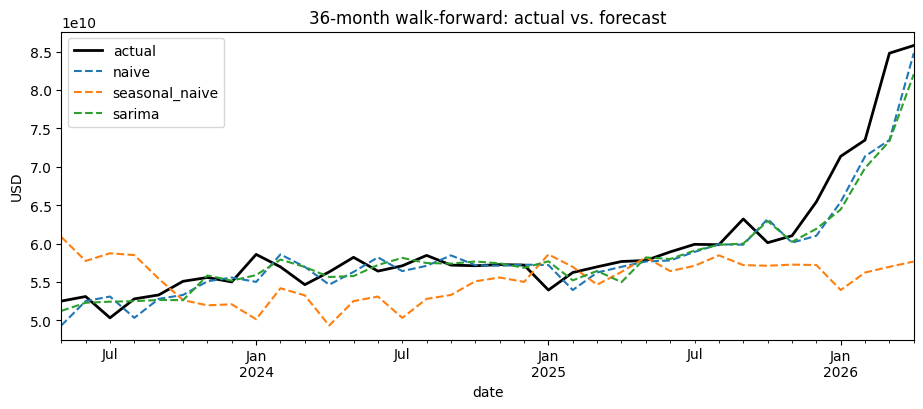

In [5]:
fig, ax = plt.subplots()
results["sarima"]["actual"].plot(ax=ax, label="actual", color="black", linewidth=2)
for name in ["naive", "seasonal_naive", "sarima"]:
    results[name]["forecast"].plot(ax=ax, label=name, linestyle="--")
ax.set_title(f"36-month walk-forward: actual vs. forecast")
ax.set_ylabel("USD")
ax.legend()
plt.show()

## Findings

SARIMA edges out the naive random walk on MAPE but not on RMSE over this
36 month window. The two land close enough that a simple random walk is a tough baseline here. That is a known feature of
one month ahead macro and trade forecasting.

Seasonal naive is clearly worse than both. Korea's export seasonality is
not stable enough year to year, given the semiconductor cycle, working day
effects, and global demand shocks, for same month last year to be a good
predictor on its own.

Because SARIMA barely separates from naive, the bar for Layer 1's
structured alt data is to meaningfully beat
a random walk.

## Key takeaways

This is the anchor. Any later layer's RMSE and MAPE gets reported against
the naive and SARIMA numbers above, not just against each other.

The closeness of naive and SARIMA is itself informative for the project's
Occam's razor question. Added structure from the seasonal ARIMA terms is
not automatically buying accuracy on this series at h=1.

Next: notebook 02 asks the most direct version of "can this baseline be
improved" - SARIMAX, this same SARIMA structure given real exogenous data -
global semiconductor billings and satellite-tracked port trade volume -
directly, rather than through a separate model. Notebooks 03-04 then try
a structurally different answer, alt-data and sentiment routed through a
GBM/Ridge on lag features benchmarked against this notebook's numbers.